In [1]:
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

In [2]:
from pathlib import Path

import astropy.units as u
import croissant as cro
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time

import mistsim as ms

%matplotlib widget

In [3]:
DATA_DIR = Path(
    "/home/christian/Documents/research/MIST/mistsim/notebooks/data/"
)

# beam
d = np.load(DATA_DIR / Path("beam.npz"))
freqs = d["freqs"]
gain = d["gain"]
theta = d["theta"]
horizon = theta <= 80
print(gain.shape, horizon.shape)

# sky
d = np.load(DATA_DIR / Path("haslam_galactic.npz"))
haslam = d["m"]
nside = d["nside"].item()
assert np.allclose(freqs, d["freqs"])  # check freqs match
print(haslam.shape, nside)

(86, 181, 360) (181,)
(86, 196608) 128


## Mapmaking

We want to write our measurement in the form
$$\mathbf{d} = \mathbf{A} \mathbf{x} + \mathbf{n},$$
where $\mathbf{d}$ is the measured data (waterfall), $\mathbf{x}$ represents the sky, $\mathbf{n}$ represents the noise, and $\mathbf{A}$ is the "design matrix" that captures the instrument response (a combination of the beam model and the rotations).

Once we have that, we can estimate the sky model from the data with Wiener filtering:
$$\mathbf{\hat{x}} = \mathbf{W} \mathbf{d},$$ where the filter matrix is
$$\mathbf{W} = \mathbf{S}\mathbf{A^T} \left(\mathbf{A}\mathbf{S}\mathbf{A^T} + \mathbf{N} \right)^{-1}$$

with a noise covariance matrix of $\mathbf{N}$ and map prior of $\mathbf{S}$.


## Simulation details

We do one frequency at a time first, so $\mathbf{x}$ is a 1d-vector of the Haslam map at a specific frequency.

While it is possible to write down the explicit form of $\mathbf{A}$, we use a trick using scipy.sparse.linalg.LinearOperator which lets us define the linear operator in terms of our mistsim simulation functions.

# Step 1: Define the linear operator and do the forward transform

In [4]:
# this is the frequency of the simulation
FREQ_IX = -1
sim_freq = freqs[FREQ_IX]
print(f"Simulation frequency = {sim_freq:.0f} MHz")

# beam and sky at the frequency, need to add a dimension for broadcating
g = gain[FREQ_IX]
beam = ms.Beam(g[None], sim_freq, sampling="mwss", horizon=horizon[:, None])

sky_map = haslam[FREQ_IX]
sky = ms.Sky(sky_map[None], sim_freq, sampling="healpix", coord="galactic")

Simulation frequency = 125 MHz


In [5]:
# forward sim params
tstart = Time("2026-02-25 12:27")
tend = tstart + 1*u.sday  # one sidereal day
times = cro.utils.time_array(t_start=tstart, t_end=tend, N_times=500)

lon = -90.74750
lat = 79.41833
alt = 150
lmax = 75

sim = ms.Simulator(beam, sky, times.jd, sim_freq, lon, lat, alt=alt, lmax=lmax)
A = ms.mapmaking.make_Amat(sim)

In [6]:
def alm1d_to_hp(alm):
    """
    Convert alm 1d with real/imag parts to healpy ordering
    """
    s = len(alm)  # one freq only for now
    lmax = int(np.sqrt(s) - 1)
    hp_len = hp.Alm.getsize(lmax)
    alm0 = alm[:lmax+1]
    almre = alm[lmax+1:hp_len]
    almim = alm[hp_len:]
    almc = 1/np.sqrt(2) * (almre + 1j*almim)
    return jnp.concatenate((alm0, almc))

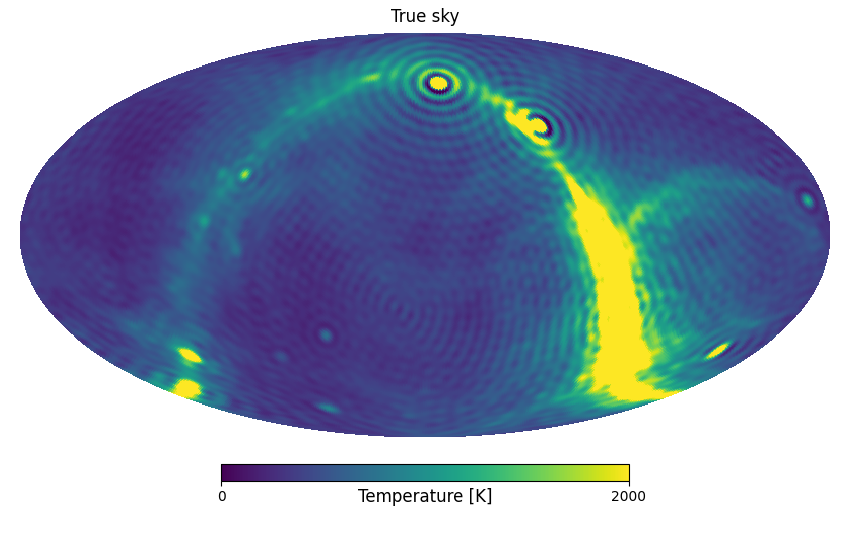

In [7]:
# create x vector
sky_alm = sky.compute_alm_eq(world="earth")
sky_alm = cro.utils.reduce_lmax(sky_alm, lmax)
x = ms.mapmaking.pack_s2fft_to_real(sky_alm)
x_hp = alm1d_to_hp(x)

hp.mollview(
    hp.alm2map(x_hp, nside),
    cbar=True, title="True sky",
    unit="Temperature [K]",
    min=0,
    max=2000,
)
plt.show()

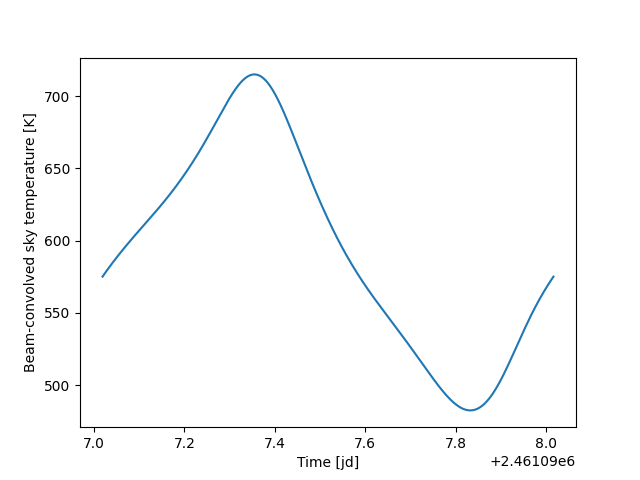

In [8]:
y = A@x
y = y.real

plt.figure()
plt.plot(times.jd, y)
plt.xlabel("Time [jd]")
plt.ylabel("Beam-convolved sky temperature [K]")
plt.show()

## Step 2: Define N and S

In [9]:
# noise: radiometer
sigma = y / np.sqrt(1e9)
Ndiag = sigma**2  # diag matrix

# prior: thikonov regularization
epsilon = 10
Sdiag = epsilon * np.ones(A.shape[1])  # diag matrix

## Step 3: Matrix Products

We need $\mathbf{S}\mathbf{A^H}$ and $\mathbf{A}\mathbf{S}\mathbf{A^H} + \mathbf{N}$. We compute them in memory efficient ways, utilizing the fact that $\mathbf{S}$ and $\mathbf{N}$ are diagonal.

In [10]:
SAT_op = ms.mapmaking.make_SAH(Sdiag, A)  # this is S @ A^H

In [11]:
# build M = ASA^H + N explictly (it's tiny)
I_m = np.eye(len(Ndiag), dtype=A.dtype)

M = A @ SAT_op @ I_m + np.diag(Ndiag)

In [12]:
Minv = np.linalg.inv(M)

In [13]:
ypn = y + np.random.normal(scale=sigma, size=len(y))
xhat = SAT_op @ Minv @ ypn

yr = A @ xhat

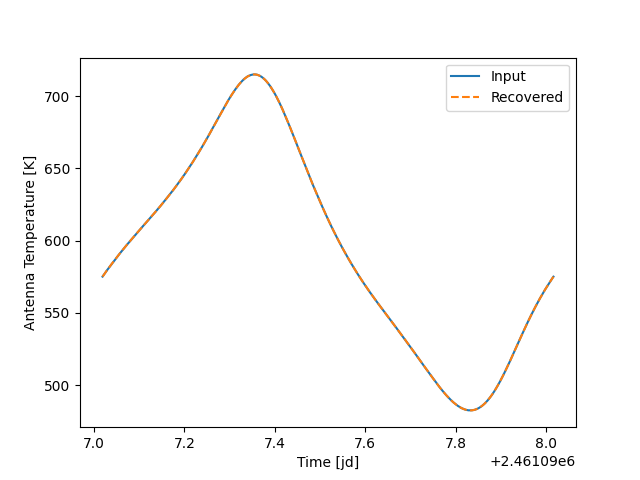

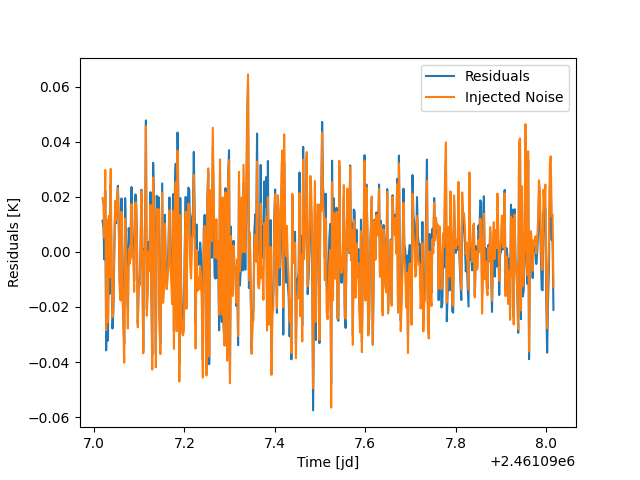

In [14]:
plt.figure()
plt.plot(times.jd, ypn, label="Input")
plt.plot(times.jd, yr, ls="--", label="Recovered")
plt.legend()
plt.xlabel("Time [jd]")
plt.ylabel("Antenna Temperature [K]")
plt.show()

plt.figure()
plt.plot(times.jd, ypn-yr, label="Residuals")
plt.plot(times.jd, ypn-y, label="Injected Noise")
plt.legend()
plt.xlabel("Time [jd]")
plt.ylabel("Residuals [K]")
plt.show()

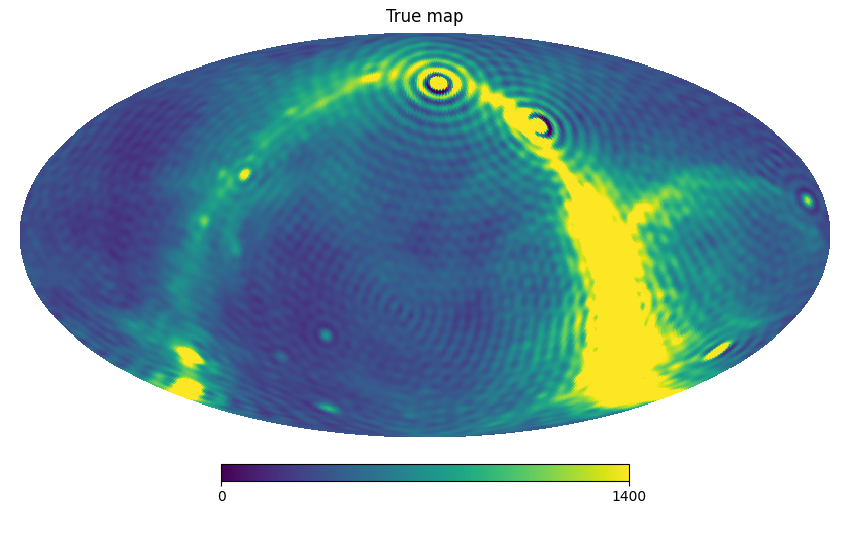

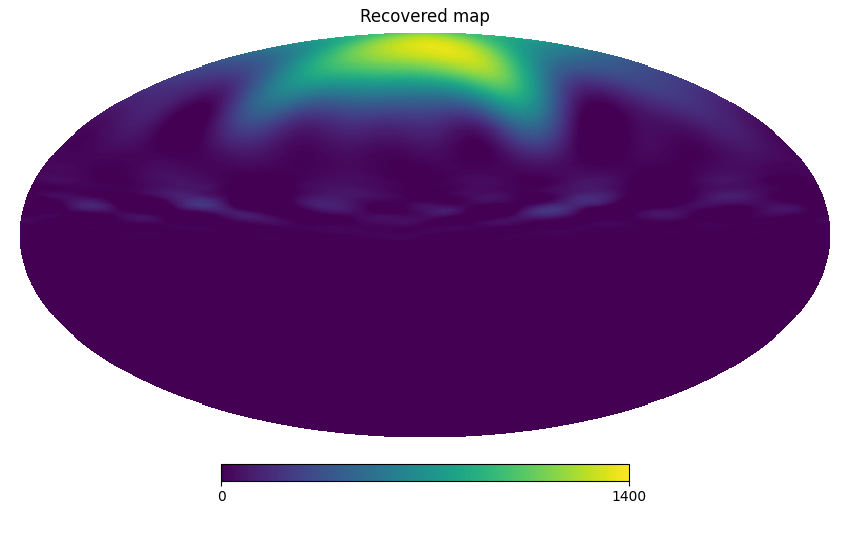

In [15]:
xhat_hp = alm1d_to_hp(xhat)
hp.mollview(hp.alm2map(x_hp, nside), title="True map", min=0, max=1400)
plt.show()
hp.mollview(
    hp.alm2map(xhat_hp, nside), title="Recovered map", min=0, max=1400
)
plt.show()